Accuracy: 0.9411764705882353

Macro Average:
Precision (Macro): 0.9583333333333334
Recall (Macro):    0.9523809523809524
F1-score (Macro):  0.9521367521367522

Weighted Average:
Precision (Weighted): 0.9485294117647058
Recall (Weighted):    0.9411764705882353
F1-score (Weighted):  0.9408748114630467

Confusion Matrix:
 [[3 0 0]
 [0 6 1]
 [0 0 7]]

Classification Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00         3
      Medium       1.00      0.86      0.92         7
        High       0.88      1.00      0.93         7

    accuracy                           0.94        17
   macro avg       0.96      0.95      0.95        17
weighted avg       0.95      0.94      0.94        17


Predicted Class: Medium


c:\Users\rajni\ml-lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


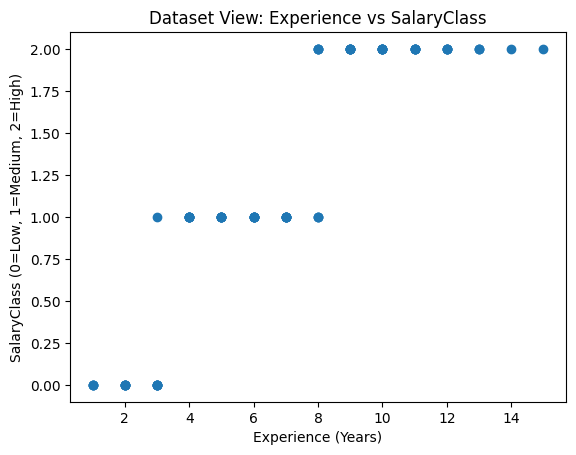

In [ ]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt 

df = pd.read_csv('employee_salary.csv') 

salary = df['Salary'] 
conditions = [ 
salary < 45000, 
(salary >= 45000) & (salary < 75000), 
salary >= 75000 
] 
choices = [0, 1, 2] 
df['SalaryClass'] = np.select(conditions, choices) 

X = df[['Experience', 'Education', 'Age']] 
y = df['SalaryClass'] 

X_train, X_test, y_train, y_test = train_test_split( 
X, y, test_size=0.2, random_state=42, stratify=y 
) 

scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

knn = KNeighborsClassifier(n_neighbors=3) 
knn.fit(X_train_scaled, y_train) 

y_pred = knn.predict(X_test_scaled) 

acc = accuracy_score(y_test, y_pred) 
prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0) 
rec_macro  = recall_score(y_test, y_pred, average='macro', zero_division=0) 
f1_macro   = f1_score(y_test, y_pred, average='macro', zero_division=0) 
prec_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0) 
rec_weighted  = recall_score(y_test, y_pred, average='weighted', zero_division=0) 
f1_weighted   = f1_score(y_test, y_pred, average='weighted', zero_division=0) 

print("Accuracy:", acc) 
print("\nMacro Average:") 
print("Precision (Macro):", prec_macro) 
print("Recall (Macro):   ", rec_macro) 
print("F1-score (Macro): ", f1_macro) 
print("\nWeighted Average:") 
print("Precision (Weighted):", prec_weighted) 
print("Recall (Weighted):   ", rec_weighted) 
print("F1-score (Weighted): ", f1_weighted) 
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred)) 
print("\nClassification Report:\n", 
classification_report(y_test, y_pred, 
target_names=['Low', 'Medium', 'High'], 
zero_division=0)) 

input_data = [[6, 16, 30]] 
input_scaled = scaler.transform(input_data) 
predicted_class = knn.predict(input_scaled)[0] 
labels = ['Low', 'Medium', 'High'] 
print("\nPredicted Class:", labels[predicted_class]) 

plt.scatter(df['Experience'], df['SalaryClass']) 
plt.xlabel("Experience (Years)") 
plt.ylabel("SalaryClass (0=Low, 1=Medium, 2=High)") 
plt.title("Dataset View: Experience vs SalaryClass") 
plt.show()